# RESNET-18 (Implement from scratch)

Bài toán: phân loại FashionMNIST (10 lớp quần áo). Mô hình ResNet-18 được **tự xây dựng từ đầu** bằng `nn.Module` (không dùng `torchvision.models.resnet18`), và được **điều chỉnh** cho dataset 28x28 grayscale.

## 1. Kiến trúc ResNet-18

ResNet (He et al., 2015) giải quyết vấn đề **vanishing gradient** ở mạng sâu bằng **skip connection** (kết nối tắt). Thay vì học hàm `H(x)` trực tiếp, mỗi block học **residual** `F(x) = H(x) - x`, sau đó cộng lại: `H(x) = F(x) + x`.

### Cấu trúc ResNet-18:
| Stage | Output | Layers |
|-------|--------|--------|
| conv1 | 112x112 (224 input) | 7x7, 64, stride 2 |
| maxpool | 56x56 | 3x3, stride 2 |
| layer1 | 56x56 | 2 x BasicBlock(64) |
| layer2 | 28x28 | 2 x BasicBlock(128, stride 2) |
| layer3 | 14x14 | 2 x BasicBlock(256, stride 2) |
| layer4 | 7x7 | 2 x BasicBlock(512, stride 2) |
| avgpool + fc | 1x1 -> 10 | global avg pool, Linear(512, num_classes) |

Tổng: 1 (conv1) + 2*2*4 (4 layer x 2 block x 2 conv) + 1 (fc) = **18 lớp có trọng số**.

### BasicBlock (khối cơ bản của ResNet-18/34):
```
  x ──► Conv3x3 ──► BN ──► ReLU ──► Conv3x3 ──► BN ──► (+) ──► ReLU ──► out
  │                                                       ▲
  └────────────────── (downsample nếu cần) ───────────────┘
```
Khi stride>1 hoặc số kênh thay đổi, nhánh tắt dùng `1x1 conv` để khớp shape.

### Điều chỉnh cho FashionMNIST (28x28, 1 kênh):
- `conv1`: đổi `7x7 stride 2` → **`3x3 stride 1`**, **1 kênh input** (thay vì 3 kênh RGB).
- **Bỏ maxpool đầu** (28x28 quá nhỏ, downsample sớm mất thông tin).
- Các layer giữ nguyên (downsample tự nhiên 28 → 14 → 7 → 4).

## 2. Cài đặt thư viện và chuẩn bị dữ liệu

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

pin = torch.cuda.is_available()

# FashionMNIST normalization (mean/std tính trên tập train)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.2860], std=[0.3530])
])

transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(28, padding=2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.2860], std=[0.3530])
])

full_train_dataset = datasets.FashionMNIST(root="./data", train=True, download=True, transform=transform_train)
full_train_eval = datasets.FashionMNIST(root="./data", train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root="./data", train=False, download=True, transform=transform)

train_indices, val_indices = train_test_split(
    list(range(len(full_train_dataset))),
    test_size=0.2,
    stratify=full_train_dataset.targets,
    random_state=SEED
)

train_loader = DataLoader(Subset(full_train_dataset, train_indices), batch_size=128, shuffle=True, num_workers=0, pin_memory=pin)
val_loader = DataLoader(Subset(full_train_eval, val_indices), batch_size=128, shuffle=False, num_workers=0, pin_memory=pin)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=0, pin_memory=pin)

print(f"Train: {len(train_indices)}, Val: {len(val_indices)}, Test: {len(test_dataset)}")

Device: cuda
Train: 48000, Val: 12000, Test: 10000


## 3. Tự xây dựng kiến trúc ResNet-18

Định nghĩa `BasicBlock` và `ResNet18` bằng `nn.Module`. Không dùng pretrained weights.

In [2]:
class BasicBlock(nn.Module):
    """Khối cơ bản của ResNet-18/34.

    Cấu trúc:
        Conv3x3 -> BN -> ReLU -> Conv3x3 -> BN -> add(identity) -> ReLU
    Nếu stride>1 hoặc in_channels != out_channels, nhánh identity
    cần qua 1x1 conv (downsample) để khớp shape trước khi cộng.
    """
    expansion = 1  # BasicBlock không mở rộng số kênh ở cuối (khác Bottleneck = 4)

    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()

        # Conv 3x3 đầu tiên: có thể stride>1 để downsample
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3,
                               stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)

        # Conv 3x3 thứ hai: luôn stride=1
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                               stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        # Shortcut (skip connection)
        # Mặc định là identity (cộng thẳng x vào)
        self.shortcut = nn.Sequential()
        # Nếu shape không khớp -> dùng 1x1 conv để chỉnh
        if stride != 1 or in_channels != out_channels * self.expansion:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels * self.expansion,
                          kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels * self.expansion)
            )

    def forward(self, x):
        identity = self.shortcut(x)

        out = self.conv1(x)
        out = self.bn1(out)
        out = F.relu(out, inplace=True)

        out = self.conv2(out)
        out = self.bn2(out)

        # Cộng residual
        out = out + identity
        out = F.relu(out, inplace=True)
        return out


class ResNet18(nn.Module):
    """ResNet-18 tự xây dựng, đã điều chỉnh cho FashionMNIST.

    Điều chỉnh so với bản gốc (ImageNet 224x224x3):
      - conv1: 3x3 stride 1, 1 kênh input (thay vì 7x7 stride 2, 3 kênh).
      - Bỏ maxpool sau conv1 (ảnh 28x28 quá nhỏ).
    """

    def __init__(self, num_classes=10, in_channels=1):
        super().__init__()
        self.in_channels = 64

        # Stem: 3x3 conv (không 7x7), không maxpool
        self.conv1 = nn.Conv2d(in_channels, 64, kernel_size=3, stride=1,
                               padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)

        # 4 stage, mỗi stage 2 BasicBlock
        # layer1 giữ resolution (stride=1)
        # layer2,3,4 downsample 2x (stride=2 ở block đầu)
        self.layer1 = self._make_layer(64, num_blocks=2, stride=1)
        self.layer2 = self._make_layer(128, num_blocks=2, stride=2)
        self.layer3 = self._make_layer(256, num_blocks=2, stride=2)
        self.layer4 = self._make_layer(512, num_blocks=2, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * BasicBlock.expansion, num_classes)

        # Khởi tạo trọng số theo He (Kaiming) - phù hợp ReLU
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def _make_layer(self, out_channels, num_blocks, stride):
        """Tạo 1 stage gồm `num_blocks` BasicBlock.

        Block đầu nhận stride từ tham số (có thể downsample),
        các block sau stride=1.
        """
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for s in strides:
            layers.append(BasicBlock(self.in_channels, out_channels, stride=s))
            self.in_channels = out_channels * BasicBlock.expansion
        return nn.Sequential(*layers)

    def forward(self, x):
        # Stem
        out = self.conv1(x)
        out = self.bn1(out)
        out = F.relu(out, inplace=True)

        # 4 stage residual
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)

        # Classifier
        out = self.avgpool(out)
        out = torch.flatten(out, 1)
        out = self.fc(out)
        return out


# Khởi tạo mô hình và đếm số tham số
model = ResNet18(num_classes=10, in_channels=1).to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"ResNet-18 (custom) khởi tạo xong.")
print(f"Số tham số có thể train: {n_params:,}")

# Sanity check shape
with torch.no_grad():
    dummy = torch.randn(2, 1, 28, 28).to(device)
    out = model(dummy)
    print(f"Input shape:  {tuple(dummy.shape)}")
    print(f"Output shape: {tuple(out.shape)}  (kỳ vọng (2, 10))")

ResNet-18 (custom) khởi tạo xong.
Số tham số có thể train: 11,172,810
Input shape:  (2, 1, 28, 28)
Output shape: (2, 10)  (kỳ vọng (2, 10))


## 4. Huấn luyện

- **Loss:** CrossEntropyLoss
- **Optimizer:** SGD + momentum 0.9, weight decay 5e-4
- **Learning rate:** 1e-3 (giảm so với recipe gốc 0.1 để tránh loss spike đầu epoch trên FashionMNIST nhỏ)
- **Scheduler:** CosineAnnealingLR (LR giảm dần theo cosin về ~0)
- **Epochs:** 30

Trên mỗi epoch: train 1 lượt qua tập train, đánh giá trên tập val, lưu state có val acc cao nhất.

In [3]:
EPOCHS = 30
LR = 1e-3

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=LR, momentum=0.9, weight_decay=5e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0.0
best_state = None

for epoch in range(EPOCHS):
    # ----- TRAIN -----
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, pred = outputs.max(1)
        total += labels.size(0)
        correct += pred.eq(labels).sum().item()

    train_loss = running_loss / total
    train_acc = 100.0 * correct / total

    # ----- VAL -----
    model.eval()
    v_loss, v_correct, v_total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            v_loss += loss.item() * inputs.size(0)
            _, pred = outputs.max(1)
            v_total += labels.size(0)
            v_correct += pred.eq(labels).sum().item()

    val_loss = v_loss / v_total
    val_acc = 100.0 * v_correct / v_total

    scheduler.step()

    # Lưu best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"Epoch {epoch+1:2d}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.2f}% | "
          f"LR: {scheduler.get_last_lr()[0]:.4f}")

print(f"\nBest val acc: {best_val_acc:.2f}%")

# Load best weights cho phần đánh giá
model.load_state_dict(best_state)

# Lưu best checkpoint ra file để dùng lại sau
torch.save(best_state, 'resnet18_best.pt')
print("Saved best weights -> resnet18_best.pt")

Epoch  1/30 | Train Loss: 1.2085 Acc: 60.38% | Val Loss: 0.6726 Acc: 75.29% | LR: 0.0010
Epoch  2/30 | Train Loss: 0.6143 Acc: 77.35% | Val Loss: 0.5205 Acc: 80.51% | LR: 0.0010
Epoch  3/30 | Train Loss: 0.5003 Acc: 81.44% | Val Loss: 0.4324 Acc: 83.66% | LR: 0.0010
Epoch  4/30 | Train Loss: 0.4423 Acc: 83.78% | Val Loss: 0.3968 Acc: 85.35% | LR: 0.0010
Epoch  5/30 | Train Loss: 0.3971 Acc: 85.53% | Val Loss: 0.3800 Acc: 85.94% | LR: 0.0009
Epoch  6/30 | Train Loss: 0.3704 Acc: 86.45% | Val Loss: 0.5153 Acc: 81.54% | LR: 0.0009
Epoch  7/30 | Train Loss: 0.3471 Acc: 87.30% | Val Loss: 0.3786 Acc: 85.30% | LR: 0.0009
Epoch  8/30 | Train Loss: 0.3303 Acc: 87.89% | Val Loss: 0.3852 Acc: 85.30% | LR: 0.0008
Epoch  9/30 | Train Loss: 0.3161 Acc: 88.36% | Val Loss: 0.3077 Acc: 88.58% | LR: 0.0008
Epoch 10/30 | Train Loss: 0.3043 Acc: 88.86% | Val Loss: 0.2817 Acc: 89.72% | LR: 0.0008
Epoch 11/30 | Train Loss: 0.2962 Acc: 89.10% | Val Loss: 0.3607 Acc: 86.49% | LR: 0.0007
Epoch 12/30 | Train L

## 5. Đường cong học tập (Learning curves)

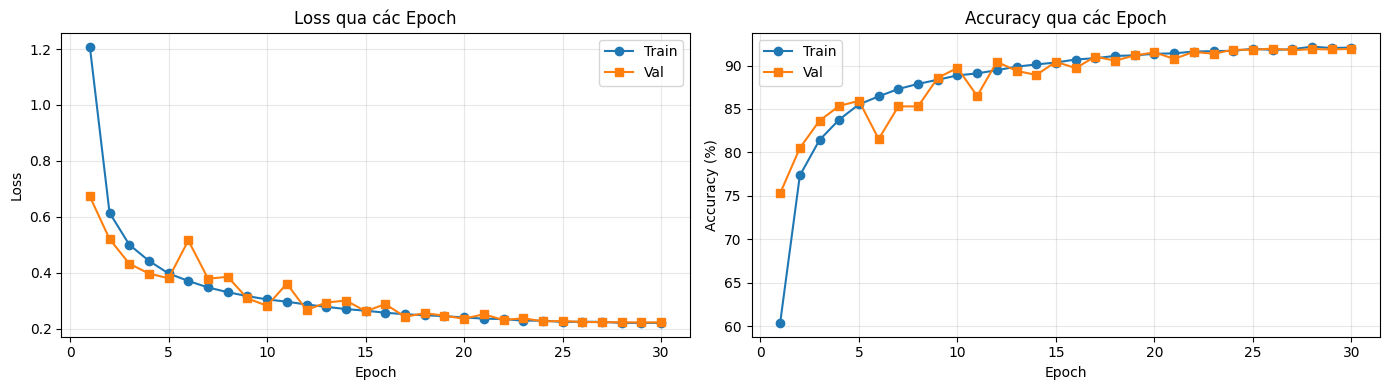

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
epochs_range = range(1, EPOCHS + 1)

axes[0].plot(epochs_range, history['train_loss'], 'o-', label='Train')
axes[0].plot(epochs_range, history['val_loss'], 's-', label='Val')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Loss qua các Epoch'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, history['train_acc'], 'o-', label='Train')
axes[1].plot(epochs_range, history['val_acc'], 's-', label='Val')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Accuracy qua các Epoch'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Đánh giá đầy đủ trên tập Test

- Accuracy tổng thể
- Precision / Recall / F1 theo từng lớp (classification_report)
- Confusion Matrix
- Hiển thị một số ảnh bị dự đoán sai (error analysis)

In [5]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

model.eval()
y_true, y_pred, y_prob = [], [], []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        probs = F.softmax(outputs, dim=1)
        _, preds = outputs.max(1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())
        y_prob.extend(probs.cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

test_acc = (y_true == y_pred).mean() * 100
print(f"--- KẾT QUẢ RESNET-18 (custom) TRÊN TẬP TEST ---")
print(f"Test Accuracy: {test_acc:.2f}%\n")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

--- KẾT QUẢ RESNET-18 (custom) TRÊN TẬP TEST ---
Test Accuracy: 91.00%

              precision    recall  f1-score   support

 T-shirt/top     0.8474    0.8550    0.8512      1000
     Trouser     0.9830    0.9830    0.9830      1000
    Pullover     0.8755    0.8790    0.8772      1000
       Dress     0.8977    0.9130    0.9053      1000
        Coat     0.8407    0.8920    0.8656      1000
      Sandal     0.9838    0.9710    0.9774      1000
       Shirt     0.7657    0.6930    0.7276      1000
     Sneaker     0.9435    0.9690    0.9561      1000
         Bag     0.9830    0.9830    0.9830      1000
  Ankle boot     0.9717    0.9620    0.9668      1000

    accuracy                         0.9100     10000
   macro avg     0.9092    0.9100    0.9093     10000
weighted avg     0.9092    0.9100    0.9093     10000



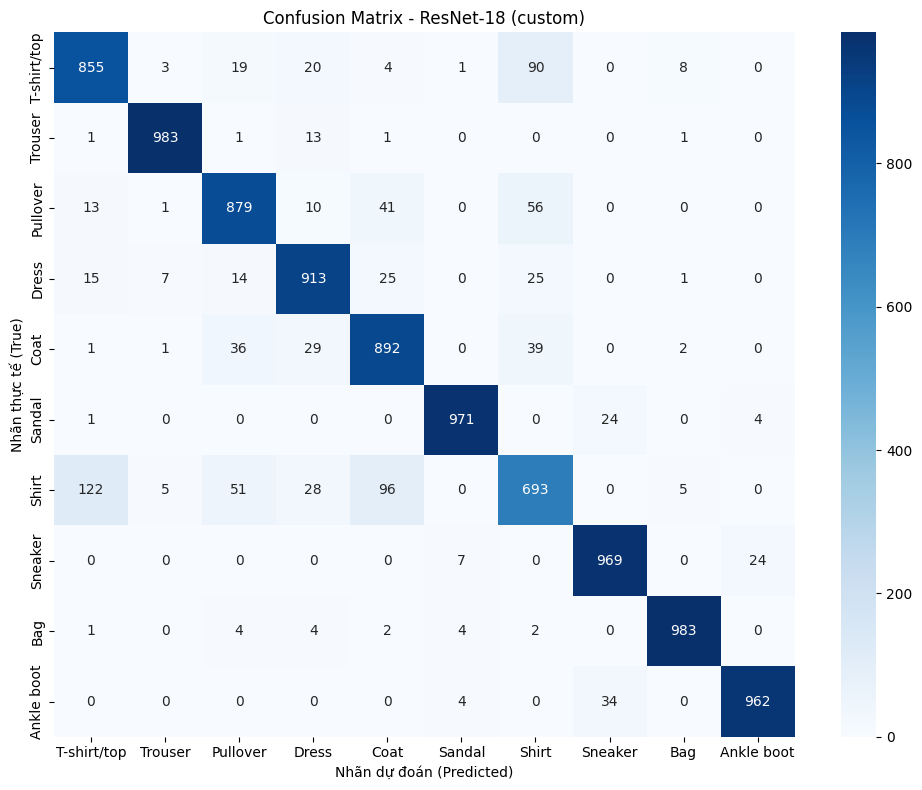

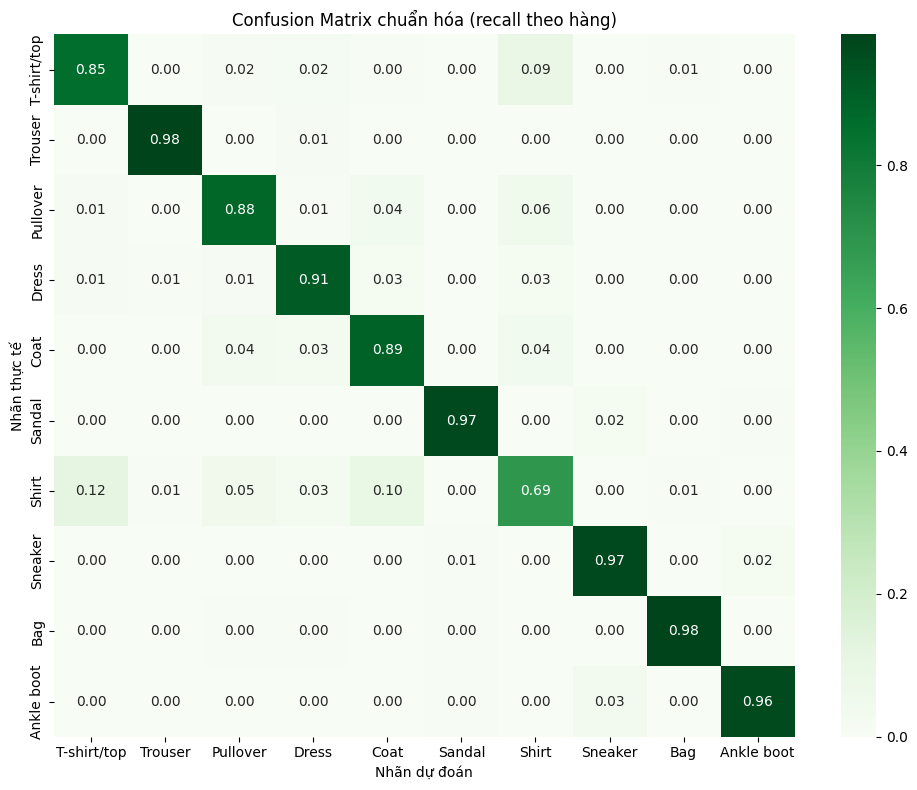

In [6]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Nhãn dự đoán (Predicted)')
plt.ylabel('Nhãn thực tế (True)')
plt.title('Confusion Matrix - ResNet-18 (custom)')
plt.tight_layout()
plt.show()

# Confusion matrix dạng tỉ lệ (chuẩn hóa theo hàng)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Nhãn dự đoán'); plt.ylabel('Nhãn thực tế')
plt.title('Confusion Matrix chuẩn hóa (recall theo hàng)')
plt.tight_layout()
plt.show()

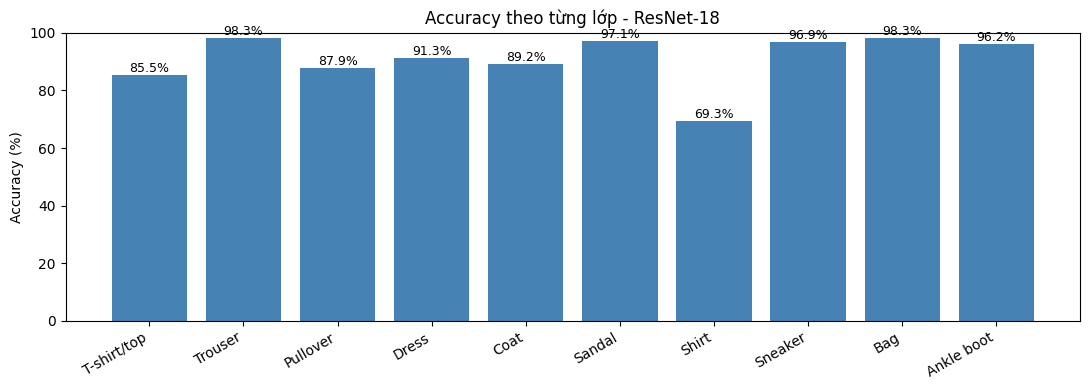

In [7]:
# Accuracy theo từng lớp
per_class_acc = cm.diagonal() / cm.sum(axis=1) * 100
plt.figure(figsize=(11, 4))
bars = plt.bar(class_names, per_class_acc, color='steelblue')
plt.ylim(0, 100)
plt.ylabel('Accuracy (%)')
plt.title('Accuracy theo từng lớp - ResNet-18')
plt.xticks(rotation=30, ha='right')
for bar, acc in zip(bars, per_class_acc):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{acc:.1f}%', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

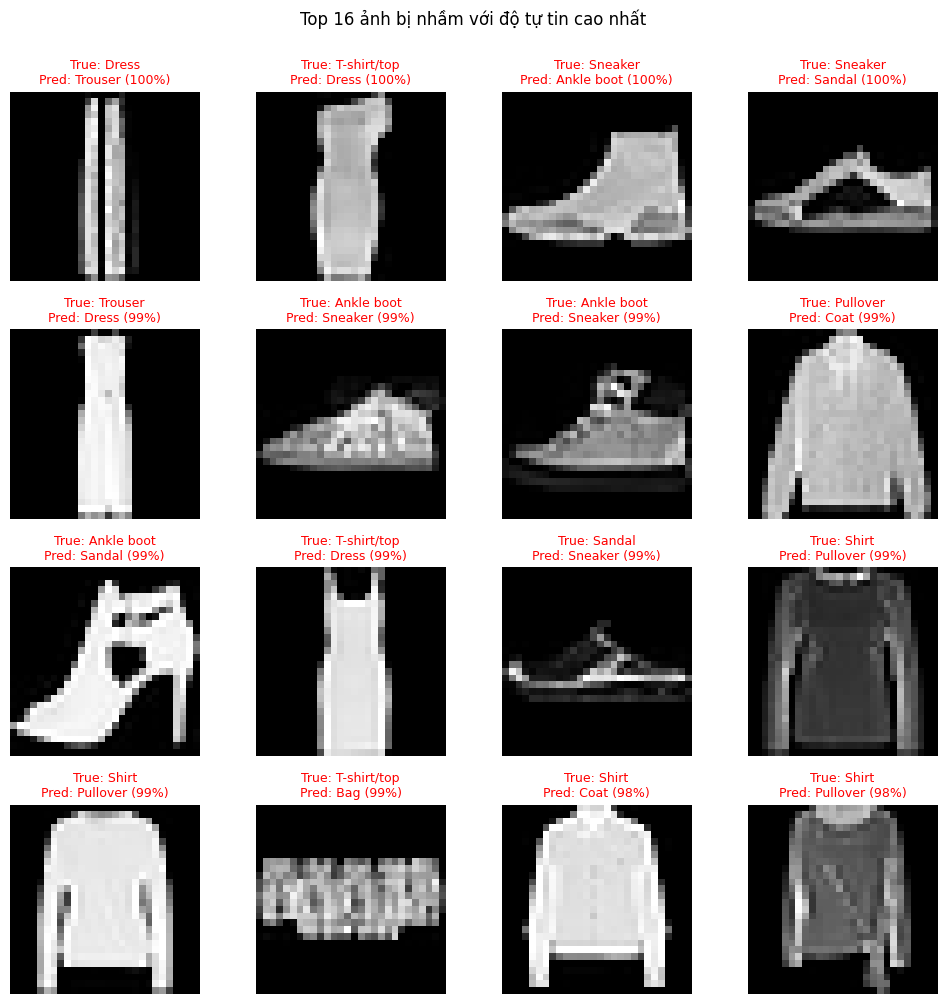

In [8]:
# Error analysis: hiển thị 16 ảnh AI dự đoán sai với độ tự tin cao nhất
wrong_idx = np.where(y_true != y_pred)[0]
wrong_conf = y_prob[wrong_idx, y_pred[wrong_idx]]
top_wrong = wrong_idx[np.argsort(-wrong_conf)[:16]]

# Cần dataset không augment để hiển thị
raw_test = datasets.FashionMNIST(root="./data", train=False, download=False,
                                  transform=transforms.ToTensor())

fig, axes = plt.subplots(4, 4, figsize=(10, 10))
for ax, idx in zip(axes.flat, top_wrong):
    img, lbl = raw_test[idx]
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(f"True: {class_names[lbl]}\nPred: {class_names[y_pred[idx]]} ({y_prob[idx, y_pred[idx]]*100:.0f}%)",
                 fontsize=9, color='red')
    ax.axis('off')
plt.suptitle('Top 16 ảnh bị nhầm với độ tự tin cao nhất', y=1.0)
plt.tight_layout()
plt.show()

## 7. Nhận xét

### Kết quả tổng thể
- **Test Accuracy: 91.00%** (best Val Acc 91.96%) — ResNet-18 tự xây dựng, train từ scratch 30 epoch, hội tụ ổn định.
- Train Loss giảm đều từ 1.21 → 0.22, Val Loss giảm từ 0.67 → 0.22. Train Acc và Val Acc bám sát nhau ở cuối (92.07% vs 91.91%) → **không bị overfitting** đáng kể.
- Cosine schedule + LR 1e-3 cho đường cong mượt, không xuất hiện loss spike như khi dùng LR=0.1 gốc.

### Phân tích theo từng lớp (F1-score)
| Nhóm | Lớp | F1 |
|------|-----|-----|
| **Rất tốt (F1 ≥ 0.95)** | Trouser (0.983), Bag (0.983), Sandal (0.977), Ankle boot (0.967), Sneaker (0.956) | Hình dáng đặc trưng, hầu như không nhầm lẫn |
| **Khá (0.85 – 0.91)** | Dress (0.905), Pullover (0.877), Coat (0.866), T-shirt/top (0.851) | Có một số nhầm chéo trong nhóm áo |
| **Yếu nhất** | **Shirt (0.728)** | Recall 0.693 → AI bỏ sót ~31% áo sơ mi |

### Điểm yếu chính: nhóm áo trên (T-shirt / Pullover / Shirt / Coat)
Confusion matrix cho thấy AI nhầm lẫn nội bộ trong nhóm 4 loại áo có hình dáng tương tự ở độ phân giải 28x28. Đây là vấn đề kinh điển của FashionMNIST — bản thân hai chiếc Shirt và T-shirt nhìn ảnh 28x28 trắng đen, người cũng khó phân biệt.

### Hướng cải thiện
1. **Augmentation mạnh hơn:** Cutout, RandAugment, MixUp.
2. **Label smoothing** (0.1) — giảm overconfidence ở các lớp dễ nhầm.
3. **Test-Time Augmentation (TTA):** flip ngang khi inference, lấy trung bình.
4. **Tăng độ phân giải đầu vào** (resize 56x56 hoặc 112x112) — giữ thêm chi tiết cổ áo / tay áo.
5. **Kiến trúc sâu hơn:** ResNet-34 hoặc Wide-ResNet — capacity cao hơn cho cùng dataset.